In [1]:
import yaml
from numpy import *
from matplotlib.pyplot import *
from brian2 import *
from numpy import random as rnd
from connectivity import connectivity

In [4]:
class Population:
    """main class to store for all yaml processing"""
    
    def __init__(self, file, geometry, population):
        """file - part of .yaml to work with population
           population - choose population from predifined subgroups in .yaml
           geometry - geometry of investigated area"""

        self.neuron_type = population
        self.file = file
        self.namespace = globals().copy()             # get access to the units in the global space

        # adding geometry variables to the instance
        for key, value in geometry.items():
            setattr(self, key, value)
            self.namespace[key] = value

        # we have to calculate amount of neurons if the formula is provided
        if isinstance(self.file['num_neurons'], str) and self.file['num_neurons']:
            self.dencity = self.file['dencity']
            if isinstance(self.dencity, str):
                self.dencity = eval(self.dencity, self.namespace)           # adding dencity first, but may be more -> this part is changable
            self.namespace['dencity'] = self.dencity                        # adding it to namespace as well

            res = int(eval(self.file['num_neurons'], self.namespace))     # amount of neurons should be int number
            self.num_neurons = res                
            self.namespace['num_neurons'] = res   # adding it to namespace as well
        else:
            self.num_neurons = self.file['num_neurons']      # for cases where initial amount is provided
            self.namespace['num_neurons'] = self.file['num_neurons']   # adding it to namespace as well

        def uniform_points_grid(L: int, H: int, N: int) -> np.array:
            """distribute given num_neurons (N) in the given 2D space L*H"""
            
            nx = int(round(np.sqrt(N * L / H)))
            ny = int(np.ceil(N / nx))
            while nx * ny < N:
                if L > H:
                    ny += 1
                else:
                    nx += 1
            base_nx_per_row = N // ny
            residuals = N % ny
            dx_total = L / nx
            dy_total = H / ny
            points = []
            for j in range(ny):
                points_in_this_row = base_nx_per_row + (1 if j < residuals else 0)
                if points_in_this_row == 0:
                    continue
                dx_row = L / points_in_this_row
                y = (j + 0.5) * dy_total
                for i in range(points_in_this_row):
                    x = (i + 0.5) * dx_row
                    points.append([x, y])

            return np.array(points)
            
        self.coord_grid = uniform_points_grid(L=self.L, H=self.H, N=self.num_neurons)
        
        self.load_constants()       # store constants from .yaml into instance
        self.load_equations()       # store equations from .yaml into instance
        self.set_neuron_group()     # creates neuron group
        
    def load_constants(self):
        """saves constans from the const section of .yaml into instance object"""

        const = self.file['const']         # choose only const part
        
        # looping through the found constants
        for name, expr in const.items():
            if isinstance(expr, str):               # only strings can be evaled
                value = eval(expr, self.namespace)  # looks for variables in the instance namespace
            else:
                value = expr
    
            setattr(self, name, value)      # adding variable "name" with value "value" to the instance namespace
            self.namespace[name] = value    # updating instance namespace with new variable

    def load_equations(self):
        """saves equations from the const section of .yaml into instance object"""
        
        eqs = self.file['equations']         # choose only equation part
        
        for name, expr in eqs.items():
            # some values here may be actual formulas
            try:                 
                expr = eval(expr, self.namespace)
            except SyntaxError:
                pass

            setattr(self, name, expr)      # adding variable "name" with value "expr" to the instance namespace
            self.namespace[name] = expr    # updating instance namespace with new variable

    def set_neuron_group(self):
        """creates a neuron group"""

        nrns = self.file['initials']       # choose only initials for neurons
        specs = self.file['specs']
        
        # create neuron group with previously saved values, all other specified parameters insert directly
        self.neurons = NeuronGroup(
                                   N=self.num_neurons,     # amount of neurons
                                   model=self.general_equ, # final equation
                                   namespace={k: v for k, v in self.namespace.items() if not k.startswith('_')},  # it doesn't like __methods
                                   **specs                 # all other specific keywords
                                  )
        
        for name, value in nrns.items():
            if isinstance(value, str):
                value = eval(value, self.namespace)     # those values are actual formulas
                setattr(self.neurons, name, value)      # adding variable "name" with value "expr" to the instance namespace
                self.namespace[name] = value            # updating instance namespace with new variable
            else:
                setattr(self.neurons, name, value)      # adding variable "name" with value "expr" to the instance namespace
                self.namespace[name] = value            # updating instance namespace with new variable


class Syns:
    """instance for working with synapses"""

    def __init__(self, desc:dict, neurons, connection_name):
        """file - part of .yaml to work with synapses
           neurons - dict with all instances of populations from .yaml
           connection_name - specific name of syn_to_syn connections from .yaml"""
        
        self.file = desc
        self.name = connection_name

        self.namespace = globals().copy()             # get access to the units in the global space

        source = self.file['source'] # just a name of population
        target = self.file['target'] # just a name of population
        
        self.source = neurons[source]  # which population of neurons to take from .yaml
        self.target = neurons[target]  # which population of neurons to take from .yaml

        self.set_synapses()
        self.set_geometry()
        self.connect()

        
    def set_synapses(self):
        """specify synapses"""

        sns = self.file['general']
        self.synapses = Synapses(self.source.neurons, self.target.neurons, **sns)

    def set_geometry(self):
        """creates the geometry of synapses"""

        self.connectivity = connectivity(
            self.name,
            self.file,
            self.source.coord_grid,
            self.target.coord_grid,
            self.source.L,
            self.source.H
            
        )

    def connect(self):
        """connects synapses"""
        presynapses = [
            pre
            for pre,post,d,gsyn,delay in self.connectivity
        ]
        postsynapses = [
            post
            for pre,post,d,gsyn,delay in self.connectivity
        ]
        self.synapses.connect(i=presynapses, j=postsynapses)
        self.synapses.gsyn = [
            gsyn
            for pre,post,d,gsyn,delay in self.connectivity
        ]
        self.synapses.delay = [
            delay*ms
            for pre,post,d,gsyn,delay in self.connectivity
        ]
        
        # if self.file['connect']:
        #     for key, value in self.file['connect'].items():
        #         if isinstance(value, str):
        #             value = eval(value, self.namespace)
        #             setattr(self.synapses, key, value)
        #             self.namespace[key] = value
        #         else:
        #             setattr(self.synapses, key, value)
        #             self.namespace[key] = value


with open('test.yaml', 'r') as file:
    f = yaml.safe_load(file)   
    
pops = {}
syns = {}
geometry = f['geometry']

for pop in f['populations']:
    pops[pop] = Population(f['populations'][pop], population=pop, geometry=geometry)
    #test = Population(f['populations'][pop], population=pop, geometry=geometry)

for syn in f['synapses']:
    syns[syn] = Syns(f['synapses'][syn], pops, connection_name=syn)
    #test = Syns(f['synapses'][syn], neurons=pops, connection_name=syn)

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\User\AppData\Local\Temp\ipykernel_19900\3930334853.py', line 102, in set_neuron_group
    self.neurons = NeuronGroup( [brian2.core.base.unused_brian_object]
WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\User\AppData\Local\Temp\ipykernel_19900\3930334853.py', line 147, in set_synapses
    self.synapses = Synapses(self.source.neurons, self.target.neurons, **sns) [brian2.core.base.unused_brian_object]
WARNING    Cannot use Cython, a test compil

Starting simulation at t=0. s for a duration of 0.5 s
0.5 s (100%) simulated in 1s


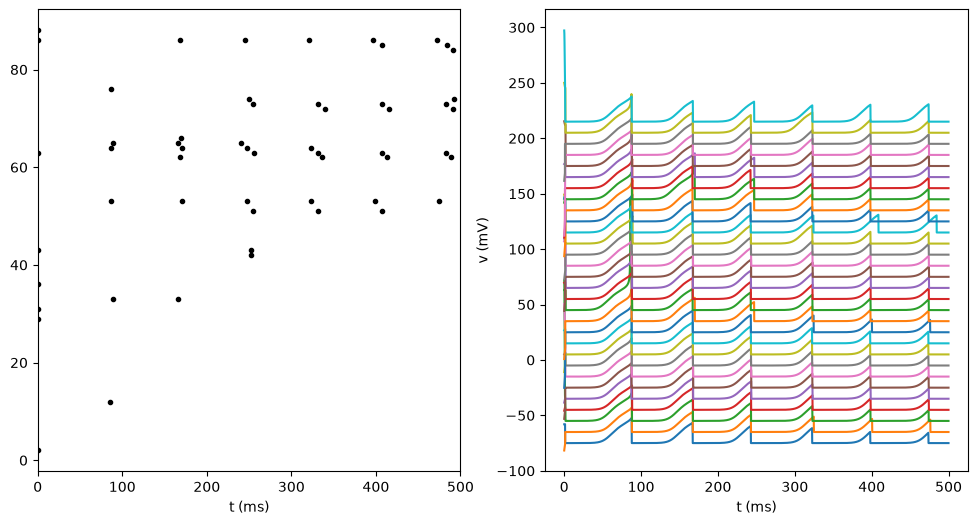

In [5]:
import brian2 as b2

# clears any ghost objects left over from previous cell runs
b2.device.reinit()
b2.start_scope()

# extract brian2 objects from your instances
active_neurons = [pop_obj.neurons for pop_obj in pops.values()]
active_synapses = [syn_obj.synapses for syn_obj in syns.values()]

# build the network containing only active objects
M = b2.StateMonitor(pops['pvbc'].neurons, 'v', record=list(range(30)))
S = b2.SpikeMonitor(pops['pvbc'].neurons)

net = b2.Network(active_neurons, active_synapses, M, S)

# run the explicit network instead of the global magic system
net.run(500 * b2.ms, report='text')

figure(figsize=(12,6))
subplot(121)
xlim(0,500)
xlabel('t (ms)')
plot(S.t/ms,S.i,'k.')
subplot(122)
for i in range(30):
    plot(M.t / ms, M[i].v / mV+10*i)
xlabel('t (ms)')
ylabel('v (mV)')
show()